In [1]:
import os

import scipy.io as spio
import numpy as np
import pandas as pd
import xarray as xr

import copernicusmarine

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.path as mpath

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmocean as cmo

/home/jjmeijer/miniconda3/envs/ocean3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cruise_id = 'sofe'
float_ids = ['f10761', 'f10762', 'f10763']
float_colors = {'f10761': 'tab:orange', 'f10762': 'tab:pink', 'f10763': 'tab:green'}

In [ ]:
# repodir = os.path.dirname(os.path.dirname(os.getcwd()))
repodir = os.path.dirname(os.path.abspath(''))
print('Repository: ', repodir)
datadir = os.path.join(repodir, 'data')
figsdir = os.path.join(repodir, 'figs')
if not os.path.exists(figsdir):
    os.makedirs(figsdir)

Repository:  /home/jjmeijer/Repos/ema-seir-pf


In [ ]:
def filedirs(float_id):
    filedirs = {
        'raw': os.path.join(datadir, cruise_id, float_id, 'raw'),
        'proc': os.path.join(datadir, cruise_id, float_id, 'proc'),
        'dec': os.path.join(datadir, cruise_id, float_id, 'proc', 'dec'),
        'vel': os.path.join(datadir, cruise_id, float_id, 'proc', 'vel')}
    return filedirs

## Load bathymetry

In [ ]:
bathy_file = os.path.join(datadir, 'gebco', 'gebco_2025_n-45.0_s-65.0_w135.0_e170.0.nc')
bathy = xr.open_dataset(bathy_file)

bathy_sel = bathy.sel(lon=slice(144, 164), lat=slice(-59, -54))

## Load SSH data

In [7]:
ssh = False
if ssh:
    # Set parameters
    data_request = {
       "dataset_id" : "cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D",
       "longitude" : [90, 100], 
       "latitude" : [-67, -60],
       "time" : ["2025-03-14", "2025-04-14"],
       "variables" : ["adt", "ugos", "vgos"]
    }
    
    # Load xarray dataset
    ssh_nrt = copernicusmarine.open_dataset(
        dataset_id = data_request["dataset_id"],
        minimum_longitude = data_request["longitude"][0],
        maximum_longitude = data_request["longitude"][1],
        minimum_latitude = data_request["latitude"][0],
        maximum_latitude = data_request["latitude"][1],
        start_datetime = data_request["time"][0],
        end_datetime = data_request["time"][1],
        variables = data_request["variables"]
    )

    # ssh_nrt['Vgos'] = ((ssh_nrt.ugos**2 + ssh_nrt.vgos**2)**(1/2)).compute() #.isel(time=-1).adt.plot(cmap=cmo.cm.balance)
    # adt_latest = ssh_nrt.adt.isel(time=-1).compute()

## Load Park and Durand (2019) ACC fronts

In [8]:
input_file = os.path.join(datadir, 'park-durand', '62985.nc')
parkdurand = xr.open_dataset(input_file)
fronts = {'SAF': 'dashed', 'PF': 'solid', 'SACCF': 'dotted'}
for front in fronts:
    idx = np.nanargmin(np.abs(parkdurand['Lon'+front].values - 180))
    parkdurand['Lon'+front].values = np.concatenate([parkdurand['Lon' + front].values[0:idx], [np.nan], parkdurand['Lon' + front].values[idx+1:]])
    parkdurand['Lat'+front].values = np.concatenate([parkdurand['Lat' + front].values[0:idx], [np.nan], parkdurand['Lat' + front].values[idx+1:]])

## Load CPIES locations

In [9]:
cpies = spio.loadmat(os.path.join(datadir, 'cpies', 'saccf-cpies-location.mat'))

cpies_id = cpies['cpies'][0][0][2]
cpies_lat = cpies['cpies'][0][0][3]
cpies_lon = cpies['cpies'][0][0][4]

station_labels = ['A2', 'A4', 'B1', 'B3', 'B5', 'C2', 'C4', 'C6', 'D1', 'D3', 'D5', 'D7', 'E2', 'E4', 'E6', 'F3']

## Get float positions

In [10]:
gps = {}
for float_id in float_ids:
    gps[float_id] = pd.read_csv(os.path.join(filedirs(float_id)['raw'], 'gps_log.txt'), names=['date', 'lat', 'lon', 'nsat'], index_col=0)
    gps[float_id] = gps[float_id].to_xarray()
    gps[float_id]['time'] = ('index', pd.DatetimeIndex(gps[float_id]['date'].values))
    gps[float_id] = gps[float_id].set_coords('time').swap_dims({'index': 'time'})
    gps[float_id] = gps[float_id].drop_vars('date')


## Show trajectory

In [11]:
central_lon = 154.5 # 98 #
min_lon = 145 # 93 #
max_lon = 164 # 101 #
central_lat = -56.5
min_lat = -59 # -66.5 #
max_lat = -54 # -63 #

n = 20
AEA = ccrs.AlbersEqualArea(central_longitude = central_lon, central_latitude = central_lat, standard_parallels = (max_lat, min_lat))
AEA._threshold = AEA._threshold/n
LC = ccrs.LambertConformal(central_longitude=central_lon, central_latitude=central_lat, standard_parallels = (max_lat, min_lat))

def make_basemap(ax):
    
    # Map the plot boundaries to the lat, lon boundaries
    # vertices = [(lon, max_lat) for lon in range(min_lon, max_lon+1, 1)] + [(lon, min_lat) for lon in range(max_lon-1, min_lon, -1)]
    vertices = list(zip(np.linspace(min_lon, max_lon, n), np.full(n, max_lat))) + \
    list(zip(np.full(n, max_lon), np.linspace(min_lat, max_lat, n))) + \
    list(zip(np.linspace(max_lon, min_lon, n), np.full(n, min_lat))) + \
    list(zip(np.full(n, min_lon), np.linspace(min_lat, max_lat, n)))
    
    boundary = mpath.Path(vertices)
    ax.set_extent([min_lon, max_lon, max_lat, min_lat])
    ax.set_boundary(boundary, transform=ccrs.PlateCarree())
    
    # Add land features and gridlines
    res = '10m'
    land = cfeature.NaturalEarthFeature('physical', 'land', res, edgecolor='black', facecolor='lightgray', linewidth=0.5)
    ax.add_feature(land, zorder=2)
    ax.gridlines(color='grey', linestyle=':', draw_labels=True, rotate_labels=False,x_inline=False, y_inline=False,), #ylocs=[-45, -60, -75])

    return ax

/tmp/ipykernel_31079/2532517800.py:2: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_31079/2532517800.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdBu')
/home/jjmeijer/miniconda3/envs/ocean3/lib/python3.12/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/jjmeijer/miniconda3/envs/ocean3/lib/python3.12/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/home/jjmeijer/miniconda3/envs/ocean3/lib/python3.12/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **

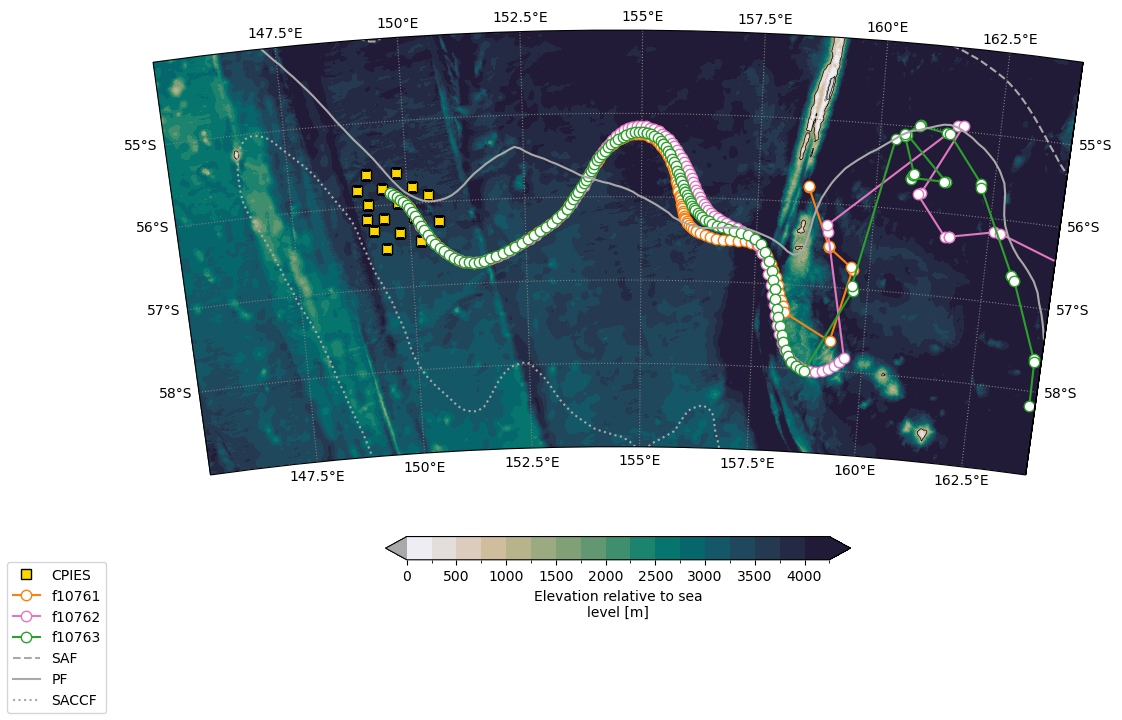

In [12]:
fig = plt.figure(figsize = (12, 8), constrained_layout=True)
fig.tight_layout()

ax = fig.add_subplot(111, projection=LC)
ax = make_basemap(ax)

# plot bathymetry
cmap = cmo.cm.rain
cmap.set_under('darkgray')
bounds = np.linspace(0, 4250, int(4250/250)+1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
(-bathy_sel.elevation).plot(ax=ax, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), 
cbar_kwargs={'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.1})
(-bathy_sel.elevation).plot.contour(ax=ax, levels=[1000], colors='k', linewidths=.5, transform=ccrs.PlateCarree())

# cpies locations
ax.plot(cpies_lon, cpies_lat, 's', markersize=7, markerfacecolor='gold', lw=.5, color='k', label='CPIES', transform=ccrs.PlateCarree())
# for i, label in enumerate(station_labels):
#     txt = ax.text(cpies_lon[i], cpies_lat[i], station_labels[i], va='bottom', ha='center', fontsize=14, color='r', linespacing=2)


# # flow streamlines
# cont = adt_latest.plot.contour(ax=ax, levels=np.linspace(-1.25, -1.5, 6), colors='k', linestyles='solid', transform=ccrs.PlateCarree())
# ax.clabel(cont, cont.levels[::2], fmt='%.2f', fontsize=10, inline=True, inline_spacing=15)

# float trajectory
for float_id in float_ids:
    ax.plot(gps[float_id].lon[1:], gps[float_id].lat[1:], '.-', label=float_id, color=float_colors[float_id], 
    markersize=15, markerfacecolor='w', transform=ccrs.PlateCarree())

# Park and Durand fronts
cmap = plt.cm.get_cmap('RdBu')  
num_colors = len(fronts)
color_values = [i / (num_colors - 1) for i in range(num_colors)]  
colors = cmap(color_values) 
for icol, front in enumerate(fronts.keys()):
    ax.plot(parkdurand['Lon' + front], parkdurand['Lat' + front], color='darkgray', linestyle=fronts[front], transform=ccrs.PlateCarree(), label=front)#color=fronts[front]

fig.legend(loc='outside lower left')

In [14]:
fig.savefig(os.path.join(figsdir, '01_overview_map.png'))